In [ ]:
pip install tensorflow 

In [ ]:
pip install tensorflow tensorflow-datasets

## Import libraries

In [76]:
import tensorflow as tf
import tensorflow_datasets as tfds
import pathlib
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from keras.utils import to_categorical
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os 

print("TensorFlow version:", tf.__version__)
print("TensorFlow Datasets version:", tfds.__version__)


TensorFlow version: 2.19.0
TensorFlow Datasets version: 4.9.9


## Load Dataset

In [62]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
#download and extract the dataset
#run once


In [63]:
data_dir = pathlib.Path(data_dir)/"flower_photos"
print("Dataset directory:", data_dir)

Dataset directory: /root/.keras/datasets/flower_photos/flower_photos


In [64]:
#check for all the folders in the dataset directory
print("\nFolder Check:\n")

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    exists = os.path.exists(class_path)
    print(f"{class_name}: {exists}")


Folder Check:

daisy: True
dandelion: True
roses: True
sunflowers: True
tulips: True


## Data Preprocessing

## Data splitting and image resizing 

In [65]:
img_height = 224
img_width = 224
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE
# TRAIN DATASET

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.


### Load the dataset, and display 10 sample images.2 flower images from 5 different classes

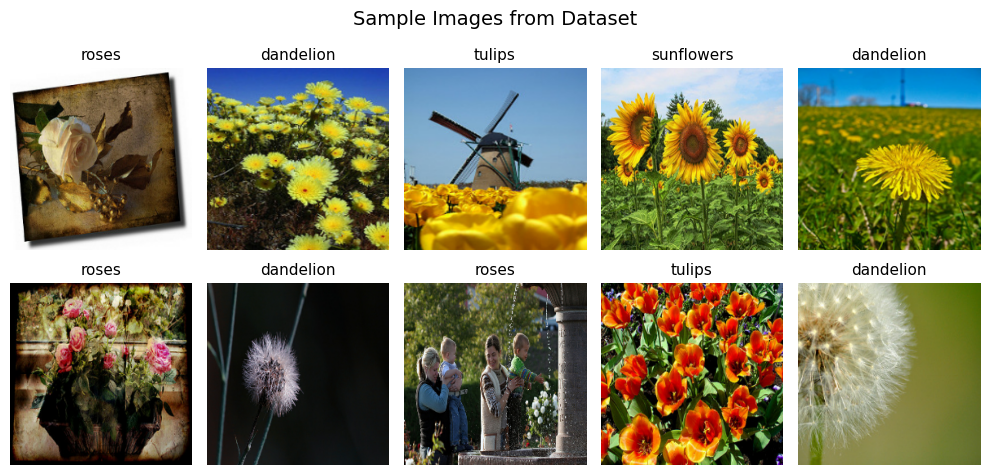

In [66]:
# Get class names

class_names = train_ds.class_names

num_images_to_display = 10

plt.figure(figsize=(10, 5))

for i, (images, labels) in enumerate(train_ds.take(1)):
    for j in range(num_images_to_display):
        plt.subplot(2, 5, j + 1)
        plt.imshow(images[j].numpy().astype("uint8"))
        plt.title(class_names[labels[j].numpy()], fontsize=11)
        plt.axis("off")

plt.suptitle("Sample Images from Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [67]:
# ============================================
# VALIDATION + TEST DATASET
# ============================================

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# ============================================
# CLASS INFORMATION
# ============================================

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5


In [68]:
# SPLIT VALIDATION + TEST 10% for each
val_test_batches = tf.data.experimental.cardinality(val_test_ds).numpy()

val_ds = val_test_ds.take(val_test_batches // 2)

test_ds = val_test_ds.skip(val_test_batches // 2)


## Normalization and Augmentation

In [69]:
#data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])
# NORMALIZATION
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (
        data_augmentation(
            normalization_layer(x),
            training=True
        ),
        y
    ),
    num_parallel_calls=AUTOTUNE
)
val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

In [70]:
# CACHE + PREFETCH


train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# VERIFY DISTRIBUTION
y_true = np.concatenate(
    [y for x, y in test_ds],
    axis=0
)

unique, counts = np.unique(y_true, return_counts=True)
print("\n========== TEST CLASS DISTRIBUTION ==========\n")

for u, c in zip(unique, counts):
    print(f"{class_names[u]} : {c}")


========== TEST CLASS DISTRIBUTION ==========

daisy : 63
dandelion : 99
roses : 56
sunflowers : 79
tulips : 85


In [71]:
# DATASET SIZE

train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_batches = tf.data.experimental.cardinality(test_ds).numpy()

print("\n========== DATASET INFORMATION ==========\n")

print("Train batches:", train_batches)
print("Validation batches:", val_batches)
print("Test batches:", test_batches)


========== DATASET INFORMATION ==========

Train batches: 92
Validation batches: 11
Test batches: 12


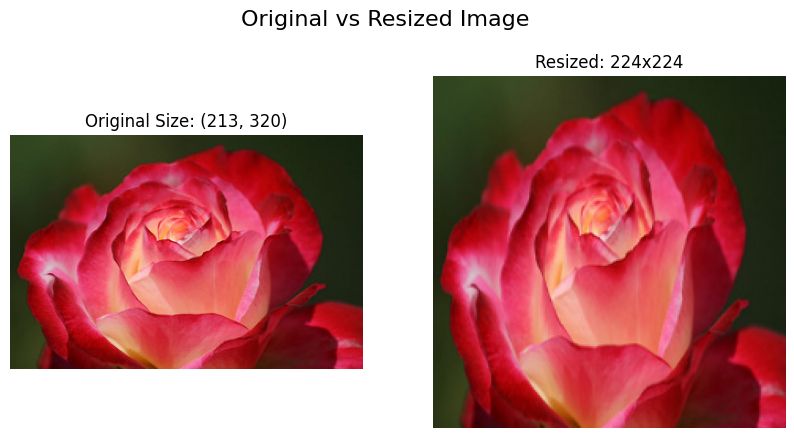

In [16]:
# Load one image manually (original size)
for image_path in data_dir.glob('*/*.jpg'):
    img = tf.keras.utils.load_img(image_path)  # original size
    img_array = tf.keras.utils.img_to_array(img)
    break

# Resize image
resized_img = tf.image.resize(img_array, (224, 224))

# Display
plt.figure(figsize=(10,5))
plt.suptitle("Original vs Resized Image", fontsize=16)
# Original Image
plt.subplot(1,2,1)
plt.imshow(img_array.astype("uint8"))
plt.title(f"Original Size: {img_array.shape[:2]}")
plt.axis("off")

# Resized Image
plt.subplot(1,2,2)
plt.imshow(resized_img.numpy().astype("uint8"))
plt.title("Resized: 224x224")
plt.axis("off")

plt.show()

### Data augmentation and normalization(e.g., random flips, rotations,zoom and translation)


### Display augmented images and original images 

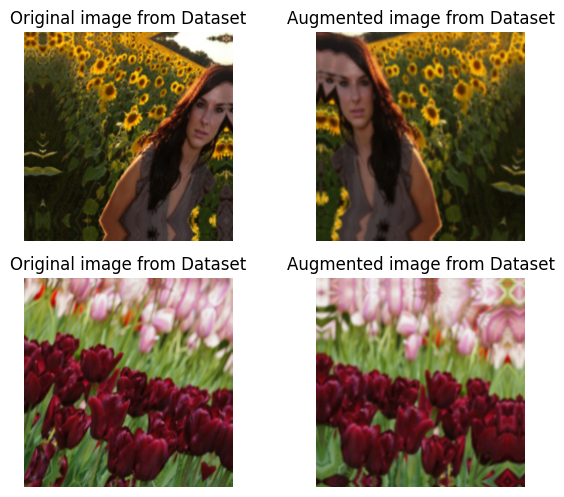

In [18]:
for images, labels in train_ds.take(1):
    original_images = images
    original_labels = labels

augmented_images = data_augmentation(original_images, training=True)

plt.figure(figsize=(6, 10))

for i in range(2):
    # Original
    ax = plt.subplot(4, 2, 2*i + 1)
    plt.imshow(original_images[i])
    plt.title("Original image from Dataset")
    plt.axis("off")

    # Augmented
    ax = plt.subplot(4, 2, 2*i + 2)
    plt.imshow(augmented_images[i])
    plt.title("Augmented image from Dataset")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Check image size

In [72]:
for images, labels in train_ds.take(1):
    print(images.shape)

(32, 224, 224, 3)


## Ensemble models

## Load trained model

In [54]:
vgg_model = load_model("/kaggle/input/datasets/jinganteo/tfds-model/vgg16_tfds_20.keras")
densenet_model = load_model("/kaggle/input/datasets/jinganteo/tfds-model/densenet_tfds_20.keras")
inception_model = load_model("/kaggle/input/datasets/jinganteo/tfds-model/inceptionV3_tfds_20.keras")

print("Models loaded successfully..")

Models loaded successfully..


## Weighted Voting
Generate prediction for each model

In [55]:
vgg_pred = vgg_model.predict(test_ds)
dense_pred = densenet_model.predict(test_ds)
inception_pred = inception_model.predict(test_ds)
#get the predictions for weighted voting from test set

12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 942ms/step


In [73]:
#checking individual model performance
y_true = np.concatenate([y for x, y in test_ds], axis=0)

vgg_acc = accuracy_score(y_true, np.argmax(vgg_pred, axis=1))
dense_acc = accuracy_score(y_true, np.argmax(dense_pred, axis=1))
inception_acc = accuracy_score(y_true, np.argmax(inception_pred, axis=1))
print("VGG16:", round(vgg_acc * 100, 2), "%")
print("DenseNet-121:", round(dense_acc * 100, 2), "%")
print("InceptionV3:", round(inception_acc * 100, 2), "%")

VGG16: 84.55 %
DenseNet-121: 90.58 %
InceptionV3: 95.29 %


To implement weighted voting, We need to find the best weight distribution for each model

In [77]:
weight_sets = {
    "VGG16 Dominant": (0.6, 0.2, 0.2),
    "DenseNet Dominant": (0.2, 0.6, 0.2),
    "Inception Dominant": (0.2, 0.2, 0.6),

    "Strong VGG16 Dominant": (0.7, 0.15, 0.15),
    "Strong DenseNet Dominant": (0.15, 0.7, 0.15),
    "Strong Inception Dominant": (0.15, 0.15, 0.7),

    "Balanced Strong Models": (0.1, 0.4, 0.5),
    "Inception Focused": (0.1, 0.2, 0.7),
    "DenseNet + Inception": (0, 0.5, 0.5),

    "DenseNet Heavy + Inception": (0.0, 0.8, 0.2),
    "Inception Heavy + DenseNet": (0.0, 0.2, 0.8),
    "VGG16 Heavy + Low DenseNet + Low Inception": (0.8, 0.1, 0.1)
}
results = []

for name, (w_vgg, w_dense, w_inception) in weight_sets.items():

    ensemble_pred = (
        w_vgg * vgg_pred +
        w_dense * dense_pred +
        w_inception * inception_pred
    )
    #Final predicted class 
    y_pred_ensemble = np.argmax(ensemble_pred, axis=1)
    #Calculate accuracy for the ensemble predictions
    ensemble_acc = accuracy_score(y_true, y_pred_ensemble)

    results.append([
        name,
        w_vgg,
        w_dense,
        w_inception,
        round(ensemble_acc * 100, 2)
    ])

# Create DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        "Ensemble Strategy",
        "VGG16 Weight",
        "DenseNet-121 Weight",
        "InceptionV3 Weight",
        "Accuracy (%)"
    ]
)

# Sort by best accuracy
results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

print("\n\t\t\t========== Weighted Voting Comparison ==========\n")

print(results_df)


			========== Weighted Voting Comparison ==========

                             Ensemble Strategy  VGG16 Weight  DenseNet-121 Weight  InceptionV3 Weight  Accuracy (%)
0                           Inception Dominant          0.20                 0.20                0.60         96.34
1                       Balanced Strong Models          0.10                 0.40                0.50         96.34
2                         DenseNet + Inception          0.00                 0.50                0.50         96.07
3                            Inception Focused          0.10                 0.20                0.70         95.81
4                   Inception Heavy + DenseNet          0.00                 0.20                0.80         95.81
5                    Strong Inception Dominant          0.15                 0.15                0.70         95.81
6                            DenseNet Dominant          0.20                 0.60                0.20         92.67
7                 

In [78]:
# DISPLAY BEST weight distribution STRATEGY
best_result = results_df.iloc[0]

print("\n========== Best weight Strategy ==========\n")

print(f"Strategy            : {best_result['Ensemble Strategy']}")
print(f"VGG16 Weight        : {best_result['VGG16 Weight']}")
print(f"DenseNet121 Weight  : {best_result['DenseNet-121 Weight']}")
print(f"InceptionV3 Weight  : {best_result['InceptionV3 Weight']}")
print(f"Best Accuracy       : {best_result['Accuracy (%)']}%")


========== Best weight Strategy ==========

Strategy            : Inception Dominant
VGG16 Weight        : 0.2
DenseNet121 Weight  : 0.2
InceptionV3 Weight  : 0.6
Best Accuracy       : 96.34%


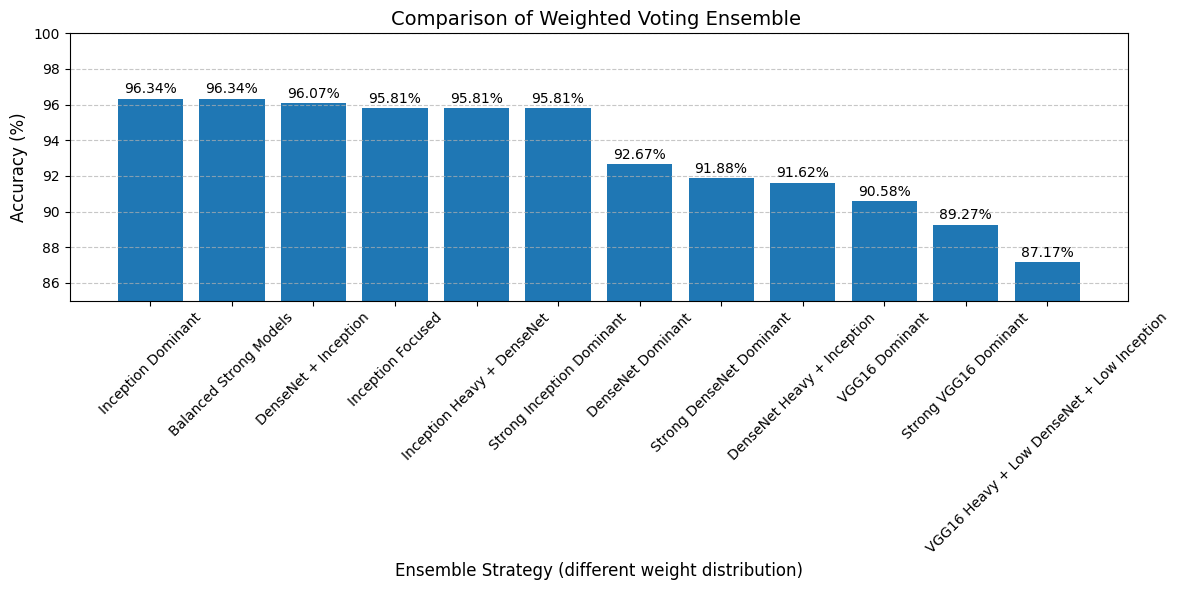

In [81]:
# Plot figure
plt.figure(figsize=(12,6))

# Bar chart
bars = plt.bar(
    results_df["Ensemble Strategy"],
    results_df["Accuracy (%)"]
)

# Labels and title
plt.xlabel("Ensemble Strategy (different weight distribution)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Comparison of Weighted Voting Ensemble ", fontsize=14)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Set y-axis range for better visualization
plt.ylim(85, 100)

# Add accuracy labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.2f}%",
        ha='center',
        fontsize=10
    )
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tight layout
plt.tight_layout()

# Show graph
plt.show()

In [82]:
#build the weighted voting model using the best weights from the weighted voting comparison
we_ensemble_pred = (
    0.2 * vgg_pred +
    0.2 * dense_pred +
    0.6 * inception_pred
)
y_pred_final_We = np.argmax(we_ensemble_pred, axis=1)

In [83]:
print("\n========== Classification Report For Weighted Voting ==========\n")
print(classification_report(
    y_true,
    y_pred_final_We,
    target_names=class_names
))
final_accuracy_we = accuracy_score(
    y_true,
    y_pred_final_We
)
#we = weighted voting
# Convert to percentage
final_accuracy_percentage_we = final_accuracy_we * 100
print(f"\nFinal Weighted Voting Test Accuracy : {final_accuracy_percentage_we:.2f}%")


========== Classification Report For Weighted Voting ==========

              precision    recall  f1-score   support

       daisy       0.95      0.98      0.97        63
   dandelion       1.00      0.97      0.98        99
       roses       0.96      0.93      0.95        56
  sunflowers       1.00      0.96      0.98        79
      tulips       0.90      0.96      0.93        85

    accuracy                           0.96       382
   macro avg       0.96      0.96      0.96       382
weighted avg       0.96      0.96      0.96       382


Final Weighted Voting Test Accuracy : 96.34%


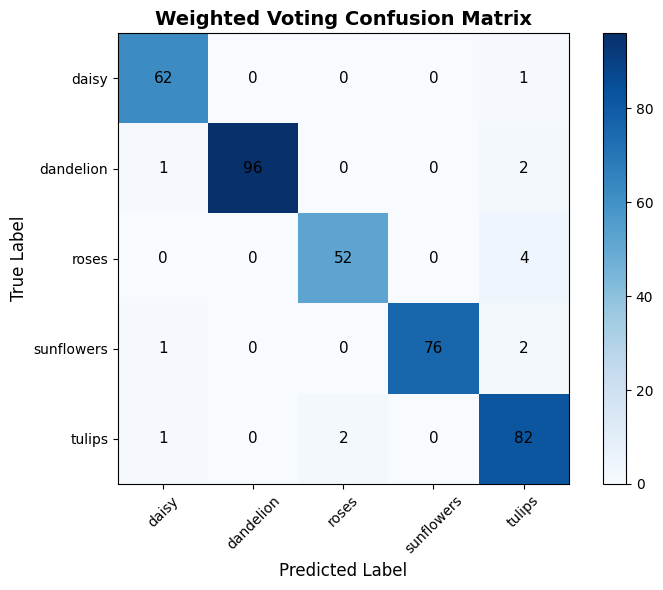

In [84]:
cm = confusion_matrix(
    y_true,
    y_pred_final_We
)
plt.figure(figsize=(8,6))

plt.imshow(cm, cmap="Blues")
# Title and labels
plt.title(
    "Weighted Voting Confusion Matrix",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    "Predicted Label",
    fontsize=12
)

plt.ylabel(
    "True Label",
    fontsize=12
)

# Tick labels using flower names
plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=11
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## Soft Voting

In [109]:
# SOFT VOTING
soft_voting_weights = (0.0, 0.33, 0.33)

pred_soft = (
    soft_voting_weights[0] * vgg_pred +
    soft_voting_weights[1] * dense_pred +
    soft_voting_weights[2] * inception_pred
)

y_pred_soft = np.argmax(pred_soft, axis=1)
print("\n========== Classification Report For Weighted Voting ==========\n")

print(classification_report(
    y_true,
    y_pred_soft,
    target_names=class_names
))
#sv - soft voting
final_accuracy_soft = accuracy_score(
    y_true,
    y_pred_soft
)
# Convert to percentage
print(f"\nFinal Weighted Voting Test Accuracy : {final_accuracy_soft * 100:.2f}%")


========== Classification Report For Weighted Voting ==========

              precision    recall  f1-score   support

       daisy       0.97      1.00      0.98        63
   dandelion       0.99      0.96      0.97        99
       roses       0.96      0.91      0.94        56
  sunflowers       1.00      0.95      0.97        79
      tulips       0.89      0.98      0.93        85

    accuracy                           0.96       382
   macro avg       0.96      0.96      0.96       382
weighted avg       0.96      0.96      0.96       382


Final Weighted Voting Test Accuracy : 96.07%


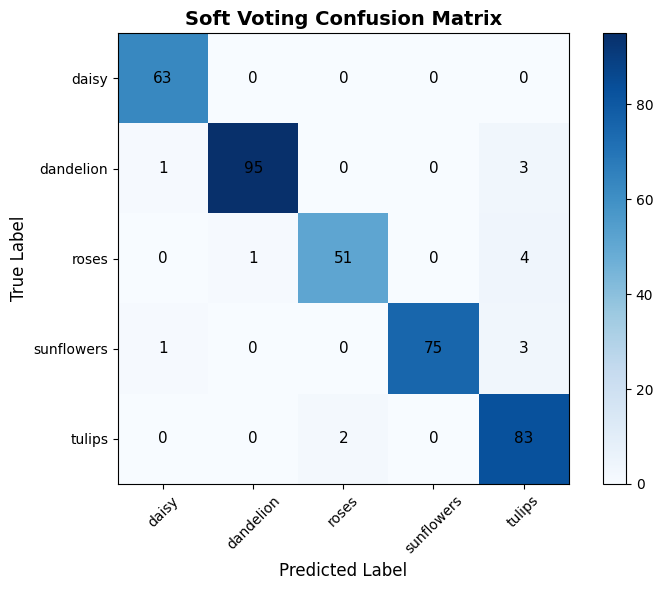

In [110]:
cm = confusion_matrix(
    y_true,
    y_pred_soft
)
plt.figure(figsize=(8,6))

plt.imshow(cm, cmap="Blues")
# Title and labels
plt.title(
    "Soft Voting Confusion Matrix",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    "Predicted Label",
    fontsize=12
)

plt.ylabel(
    "True Label",
    fontsize=12
)

# Tick labels using flower names
plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=11
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## Stacking
Stacking (Stacked Generalization) is an advanced ensemble learning method that combines multiple base models using a Machine Learning Meta-Classifier.

Instead of relying on heuristic weighted voting, stacking trains a supervised learning model to learn how to optimally combine the predicted class probabilities of the base models (VGG16, DenseNet121, InceptionV3) to maximize classification accuracy.

In [91]:
# Generate validation set predictions to construct training features for the meta-classifier
print("Generating validation set predictions for Stacking meta-training...")
y_val_true = np.concatenate([y for x, y in val_ds], axis=0)
vgg_val_pred = vgg_model.predict(val_ds)
dense_val_pred = densenet_model.predict(val_ds)
inception_val_pred = inception_model.predict(val_ds)

# Concatenate probability distributions horizontally to form features (shape: [num_samples, 15])
X_val_meta = np.hstack([vgg_val_pred, dense_val_pred, inception_val_pred])
print("Validation Stacking features shape:", X_val_meta.shape)
print("Validation labels shape:", y_val_true.shape)

Generating validation set predictions for Stacking meta-training...
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
Validation Stacking features shape: (352, 15)
Validation labels shape: (352,)


In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Construct test features from the pre-computed baseline model predictions
X_test_meta = np.hstack([vgg_pred, dense_pred, inception_pred])

# Define meta-classifiers to compare
meta_classifiers = {
    "Stacking (Logistic Regression)": LogisticRegression(max_iter=1000, random_state=42),
    "Stacking (Random Forest)": RandomForestClassifier(n_estimators=100, random_state=42),
    "Stacking (Support Vector Machine)": SVC(probability=True, random_state=42),
    "Stacking (Gradient Boosting)": GradientBoostingClassifier(random_state=42)
}
# to compare which is the best meta-classifier and implemented as a stacking ensemble model
stacking_results = {}
print("\n========== Training Meta-Classifiers for Stacking ==========\n")
for name, clf in meta_classifiers.items():
    clf.fit(X_val_meta, y_val_true)
    y_pred_stack = clf.predict(X_test_meta)
    acc = accuracy_score(y_true, y_pred_stack)
    stacking_results[name] = (clf, acc, y_pred_stack)
    print(f"{name} Test Accuracy : {acc * 100:.2f}%")


========== Training Meta-Classifiers for Stacking ==========

Stacking (Logistic Regression) Test Accuracy : 96.86%
Stacking (Random Forest) Test Accuracy : 98.17%
Stacking (Support Vector Machine) Test Accuracy : 97.12%
Stacking (Gradient Boosting) Test Accuracy : 97.38%



========== Stacking Ensemble Comparison ==========

                     Meta-Classifier  Accuracy (%)
1           Stacking (Random Forest)         98.17
3       Stacking (Gradient Boosting)         97.38
2  Stacking (Support Vector Machine)         97.12
0     Stacking (Logistic Regression)         96.86


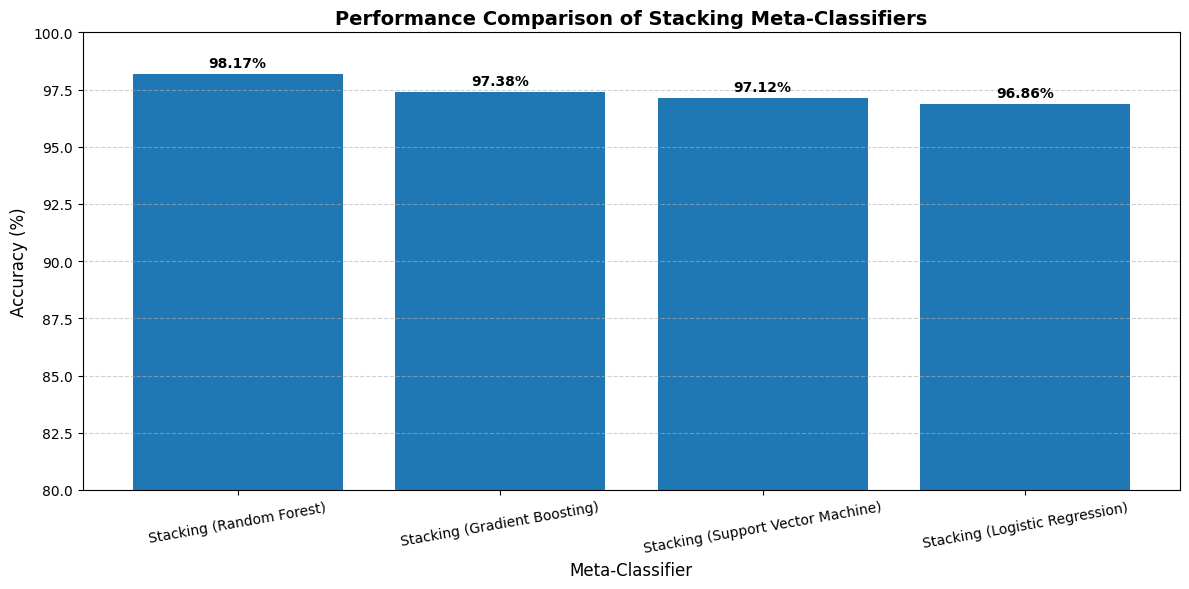

In [94]:
stacking_comparison_df = pd.DataFrame({

    "Meta-Classifier": list(stacking_results.keys()),

    "Accuracy (%)": [
        round(acc * 100, 2)
        for (_, acc, _) in stacking_results.values()
    ]
})

# Sort results from highest to lowest accuracy
stacking_comparison_df = stacking_comparison_df.sort_values(
    by="Accuracy (%)",
    ascending=False
)

# =========================
# DISPLAY TABLE
# =========================

print("\n========== Stacking Ensemble Comparison ==========\n")

print(stacking_comparison_df)
# =========================
# STACKING RESULTS VISUALIZATION
# =========================

plt.figure(figsize=(12,6))

bars = plt.bar(
    stacking_comparison_df["Meta-Classifier"],
    stacking_comparison_df["Accuracy (%)"]
)

# Add accuracy labels above bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.2f}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Title
plt.title(
    "Performance Comparison of Stacking Meta-Classifiers",
    fontsize=14,
    fontweight='bold'
)

# Axis labels
plt.xlabel(
    "Meta-Classifier",
    fontsize=12
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=12
)

# Rotate x-axis labels
plt.xticks(
    rotation=10,
    fontsize=10
)

# Better visualization range
plt.ylim(80, 100)

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

# Tight layout
plt.tight_layout()

# Show graph
plt.show()

In [95]:
# Select the best meta-classifier based on test performance
best_stacking_name = max(stacking_results, key=lambda k: stacking_results[k][1])
best_clf, stacking_accuracy, y_pred_stacking = stacking_results[best_stacking_name]

print(f"\n========== Best Stacking Strategy ==========\n")
print(f"Meta-Classifier : {best_stacking_name}")
print(f"Accuracy        : {stacking_accuracy * 100:.2f}%")

print("\n========== Classification Report For Stacking ==========\n")
print(classification_report(y_true, y_pred_stacking, target_names=class_names))
stacking_accuracy_percentage = stacking_accuracy * 100


========== Best Stacking Strategy ==========

Meta-Classifier : Stacking (Random Forest)
Accuracy        : 98.17%

========== Classification Report For Stacking ==========

              precision    recall  f1-score   support

       daisy       0.98      1.00      0.99        63
   dandelion       1.00      0.99      0.99        99
       roses       0.95      0.96      0.96        56
  sunflowers       1.00      0.99      0.99        79
      tulips       0.96      0.96      0.96        85

    accuracy                           0.98       382
   macro avg       0.98      0.98      0.98       382
weighted avg       0.98      0.98      0.98       382



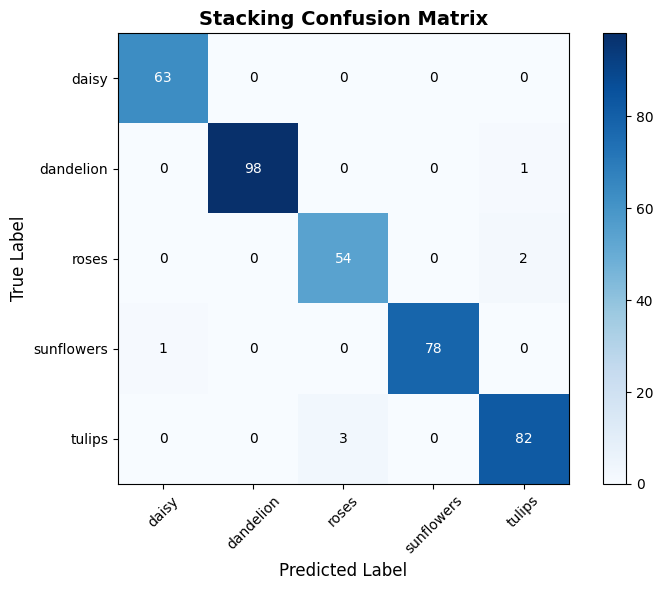

In [96]:
# Plot Stacking Confusion Matrix
cm_stacking = confusion_matrix(y_true, y_pred_stacking)
plt.figure(figsize=(8,6))
plt.imshow(cm_stacking, cmap="Blues")
plt.title(f"Stacking Confusion Matrix", fontsize=14, fontweight='bold')
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm_stacking[i, j], ha="center", va="center", 
                 color="white" if cm_stacking[i, j] > cm_stacking.max()/2 else "black")

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()


## Final Comparison


========== Final Model Comparison ==========

             Model  Accuracy (%)
0            VGG16         84.55
1      DenseNet121         90.58
2      InceptionV3         95.29
3      Soft Voting         96.07
4  Weighted Voting         96.34
5        Stacking          98.17


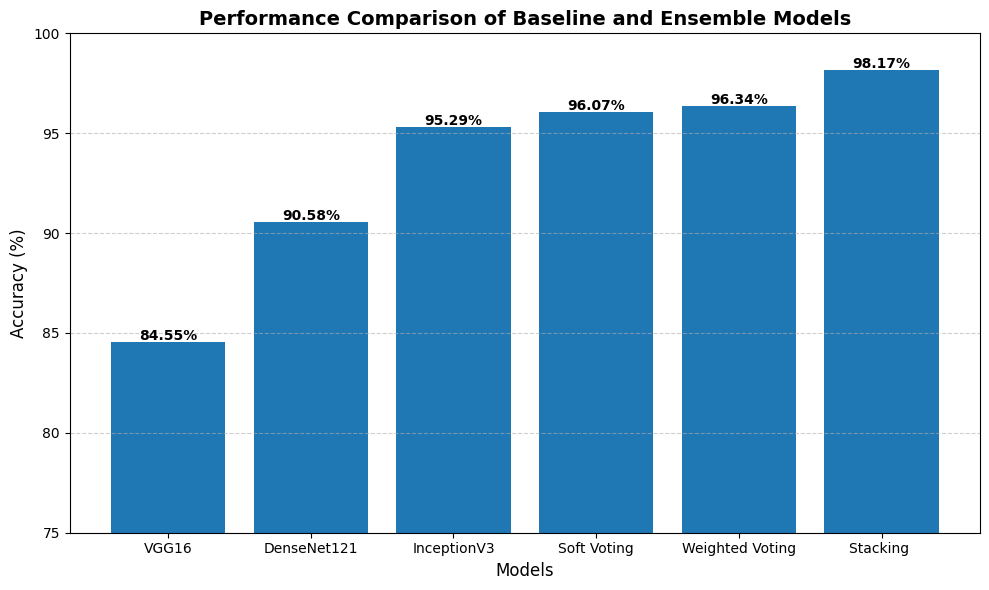

In [114]:
# FINAL MODEL COMPARISON
comparison_results = {
    "Model": [
        "VGG16",
        "DenseNet121",
        "InceptionV3",
        "Soft Voting",
        "Weighted Voting",
        "Stacking "
    ],
    "Accuracy (%)": [
        round(vgg_acc * 100, 2),
        round(dense_acc * 100, 2),
        round(inception_acc * 100, 2),
        round(final_accuracy_soft * 100, 2),
        round(final_accuracy_percentage_we, 2),
        round(stacking_accuracy_percentage, 2)
    ]
}

# CREATE DATAFRAME

comparison_df = pd.DataFrame(comparison_results)
# DISPLAY TABLE
print("\n========== Final Model Comparison ==========\n")

print(comparison_df)

plt.figure(figsize=(10,6))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy (%)"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{height:.2f}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Performance Comparison of Baseline and Ensemble Models",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    "Models",
    fontsize=12
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=12
)

# Better visualization range
plt.ylim(75, 100)

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()
plt.show()